# MaalstroomicFlow — combined behavior and tuning diagnostics

Per-animal MaalstroomicFlow workspace: drives the behavior (lick scatter, trial outcomes) and tuning (sorted / classified heatmaps, place-cell peak-location distribution before vs after reward shift) plot helpers from a single selection. Edit the selection cell in section 2 to switch dataset, animal, session range, before/after groups, or trial type — every downstream cell consumes the resolved selection without further edits.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running plot cells picks up helper changes without reloading.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import cmocean

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    LickContext,
    TrialOutcomeContext,
    aggregate_lick_events,
    aggregate_trial_outcomes,
    plot_classified_heatmap,
    plot_lick_scatter,
    plot_place_cell_peak_distribution_around_shift,
    plot_sorted_heatmap,
    plot_trial_outcomes,
)

## 2. Selection

The only cell to edit when switching datasets, animals, sessions, or trial types. `DATASET_PATH` is the dataset root, `ANIMAL` is a single animal id, `DISPLAY_SESSIONS` is a tuple of 1-indexed chronological session numbers shared by every per-session plot below (`None` renders every session in the animal's list), `BEFORE_SHIFT_SESSIONS` / `AFTER_SHIFT_SESSIONS` pick the two groups averaged together for the place-cell peak-location distribution figure, and `TRIAL_TYPE` selects which trial type the tuning helpers evaluate (set to `None` to fall back to the first trial type in each helper's own resolution path).

In [2]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "11"
DISPLAY_SESSIONS: tuple[int, ...] | None = (16, 17, 18, 19, 20)
TRIAL_TYPE: str | None = None
# 1-indexed session numbers averaged together for the peak-distribution figure (5 days before
# the reward shift and 5 days after). Adjust to match this animal's actual shift day.
BEFORE_SHIFT_SESSIONS: tuple[int, ...] = (11, 12, 13, 14, 15)
AFTER_SHIFT_SESSIONS: tuple[int, ...] = (16, 17, 18, 19, 20)

## 3. Load

Reads the dataset, builds the chronologically sorted `sessions` tuple for the selected animal, and assembles the per-animal behavior contexts (`lick_context`, `outcome_context`) consumed by section 4. Tuning helpers in section 5 read `sessions`, `DISPLAY_SESSIONS`, `BEFORE_SHIFT_SESSIONS`, `AFTER_SHIFT_SESSIONS`, and `trial_type` directly.

In [3]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
if not sessions:
    raise RuntimeError(f"animal {ANIMAL!r} has no sessions in dataset {dataset.name!r}")

lick_context: LickContext = aggregate_lick_events(sessions=sessions)
outcome_context: TrialOutcomeContext = aggregate_trial_outcomes(sessions=sessions)
trial_type: str | None = TRIAL_TYPE

## 4. Behavior outputs

Per-animal behavior plots restricted to `DISPLAY_SESSIONS`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Lick scatter

Discrete rising-edge lick events scattered in (within-trial position, cumulative trial index) coordinates, with per-trial reward-zone rectangles drawn from each block's resolved geometry. Trial-type and geometry shifts (longitudinal mid-recording reward-zone shifts or intra-session multi-trial-type recordings) appear as different per-trial rectangles with the same color coding (rewarded vs non-rewarded relative to the trial's own reward zone).

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render.

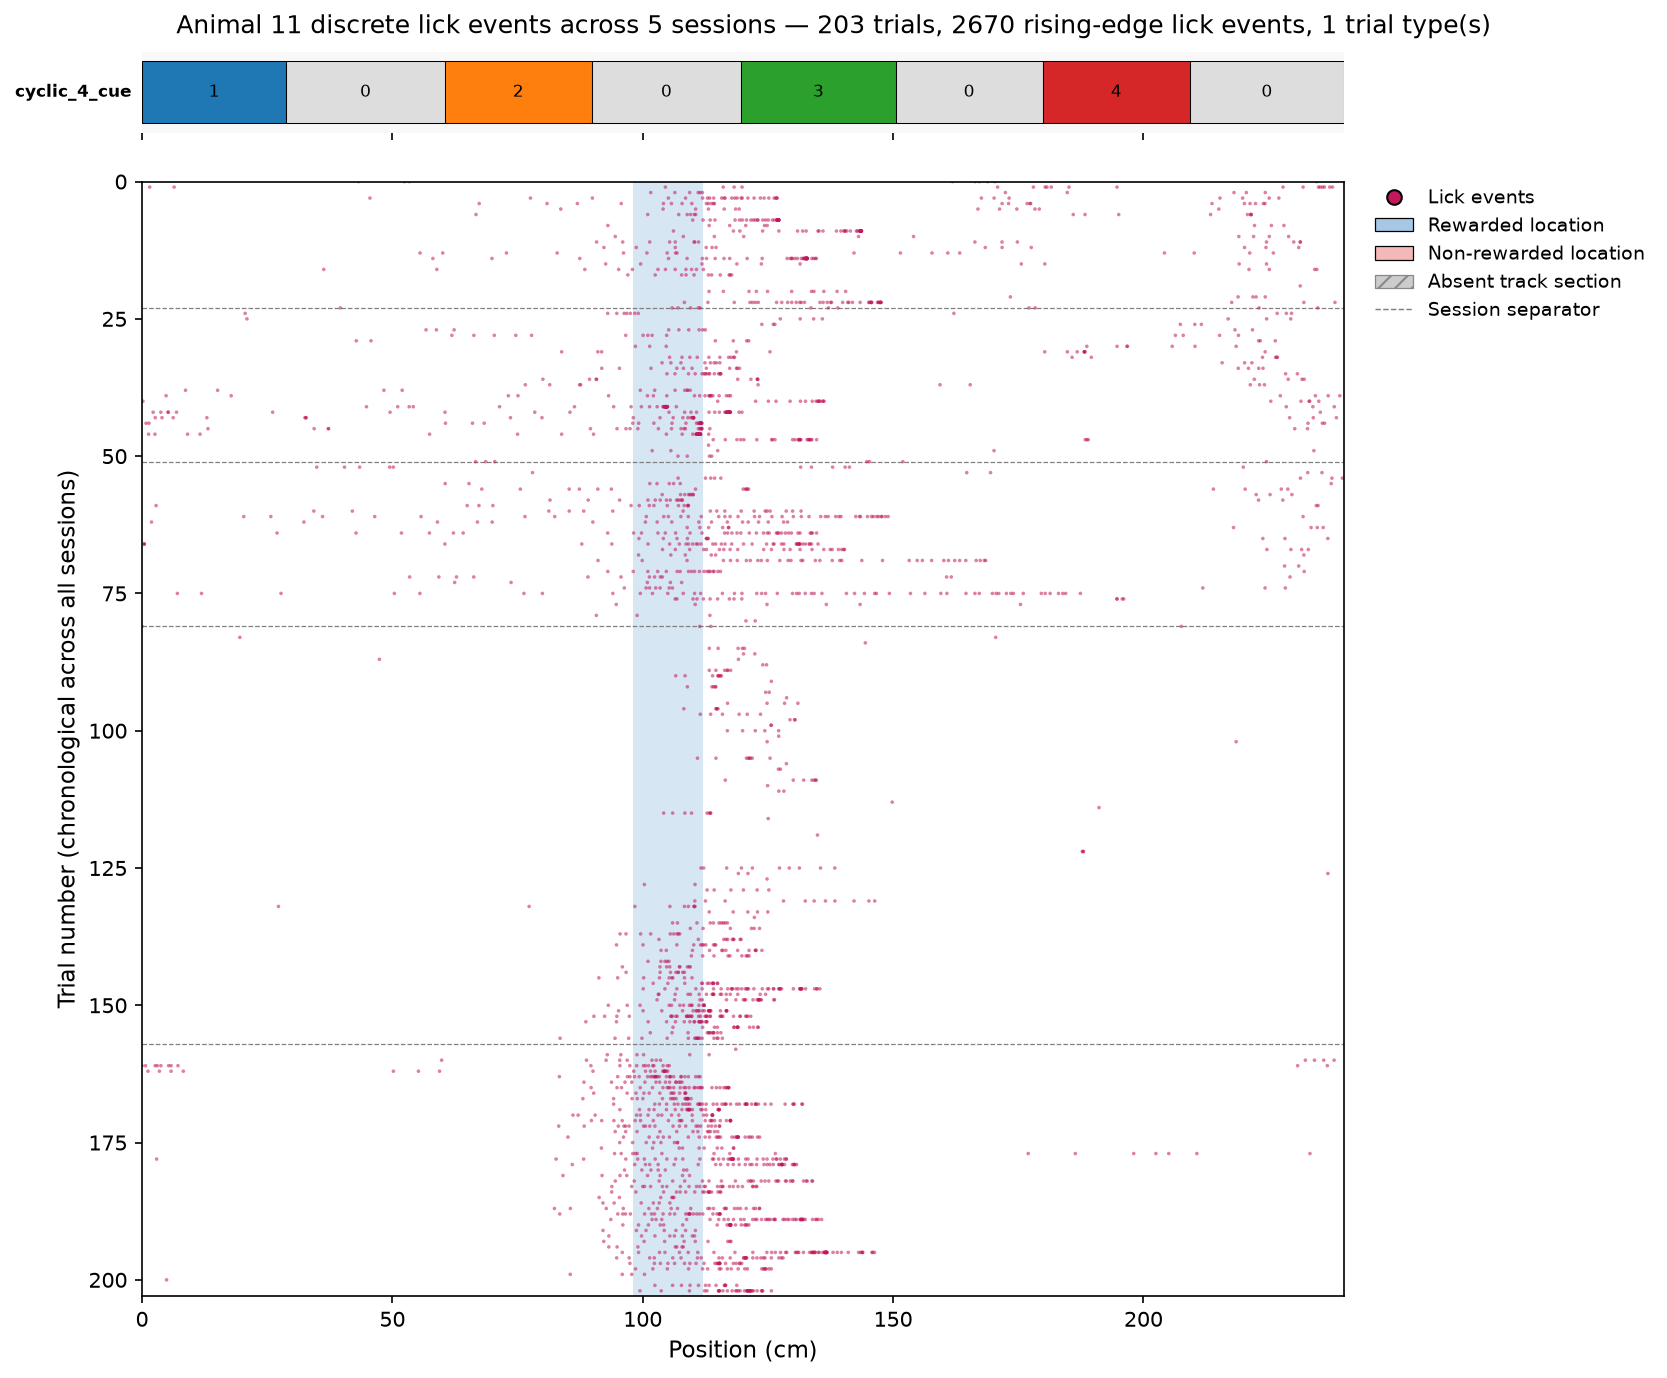

In [4]:
plot_lick_scatter(
    context=lick_context,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
)
plt.show()

### 4.2 Trial outcomes across sessions

Per-session stacked bar chart of success / failure / guided trial counts for the animal, with a success-rate trace overlaid on a secondary y-axis. A trial is classified as **guided** when any of its samples has ``reinforcing_guided`` or ``aversive_guided`` set; **success** when the trial is not guided and any sample has ``reward > 0``; **failure** otherwise. Guided trials are excluded from the success-rate denominator so the rate tracks the animal's earned-reward fraction rather than reflecting training-phase guidance.

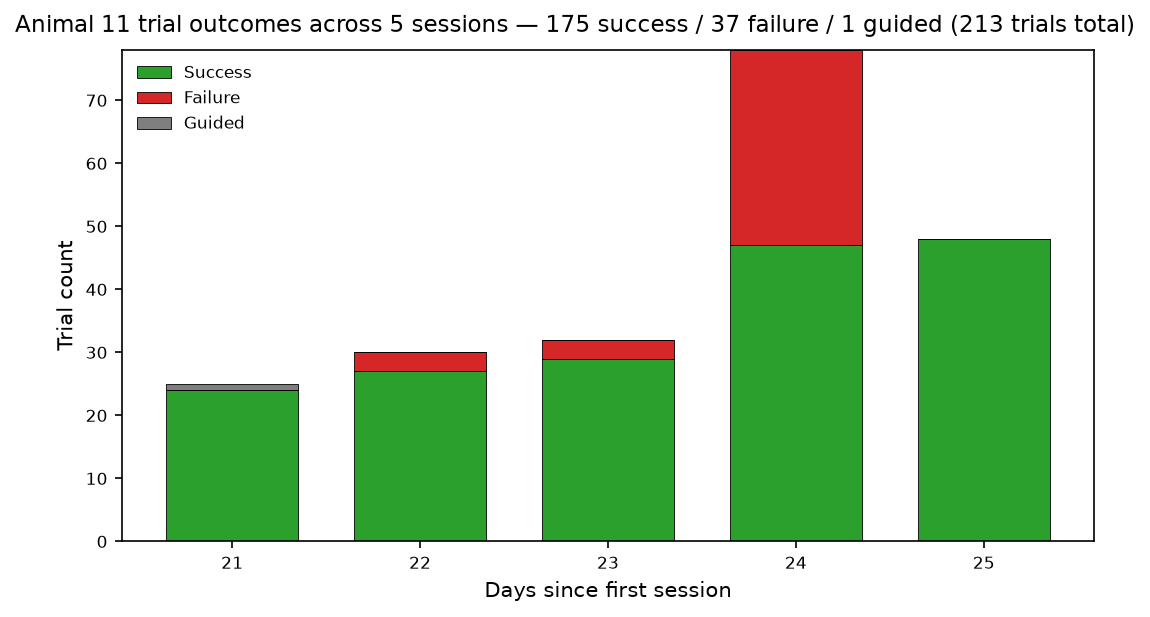

In [5]:
plot_trial_outcomes(
    context=outcome_context,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
)
plt.show()

## 5. Tuning outputs

Per-session tuning plots restricted to `DISPLAY_SESSIONS` (sections 5.1 and 5.2). Section 5.3 averages over the `BEFORE_SHIFT_SESSIONS` and `AFTER_SHIFT_SESSIONS` groups instead.

### 5.1 Per-day-sorted rate maps — all cells

Per-session view across the animal's selected session range: every registered cell renders as a row, sorted independently by *that session's* peak position. Rate maps are raw ΔF/F₀ on a shared percentile-clipped color scale so amplitudes are directly comparable between panels. Use this view for a global sense of the population's tuning band; pair with section 5.3 for the active-cell-only band.

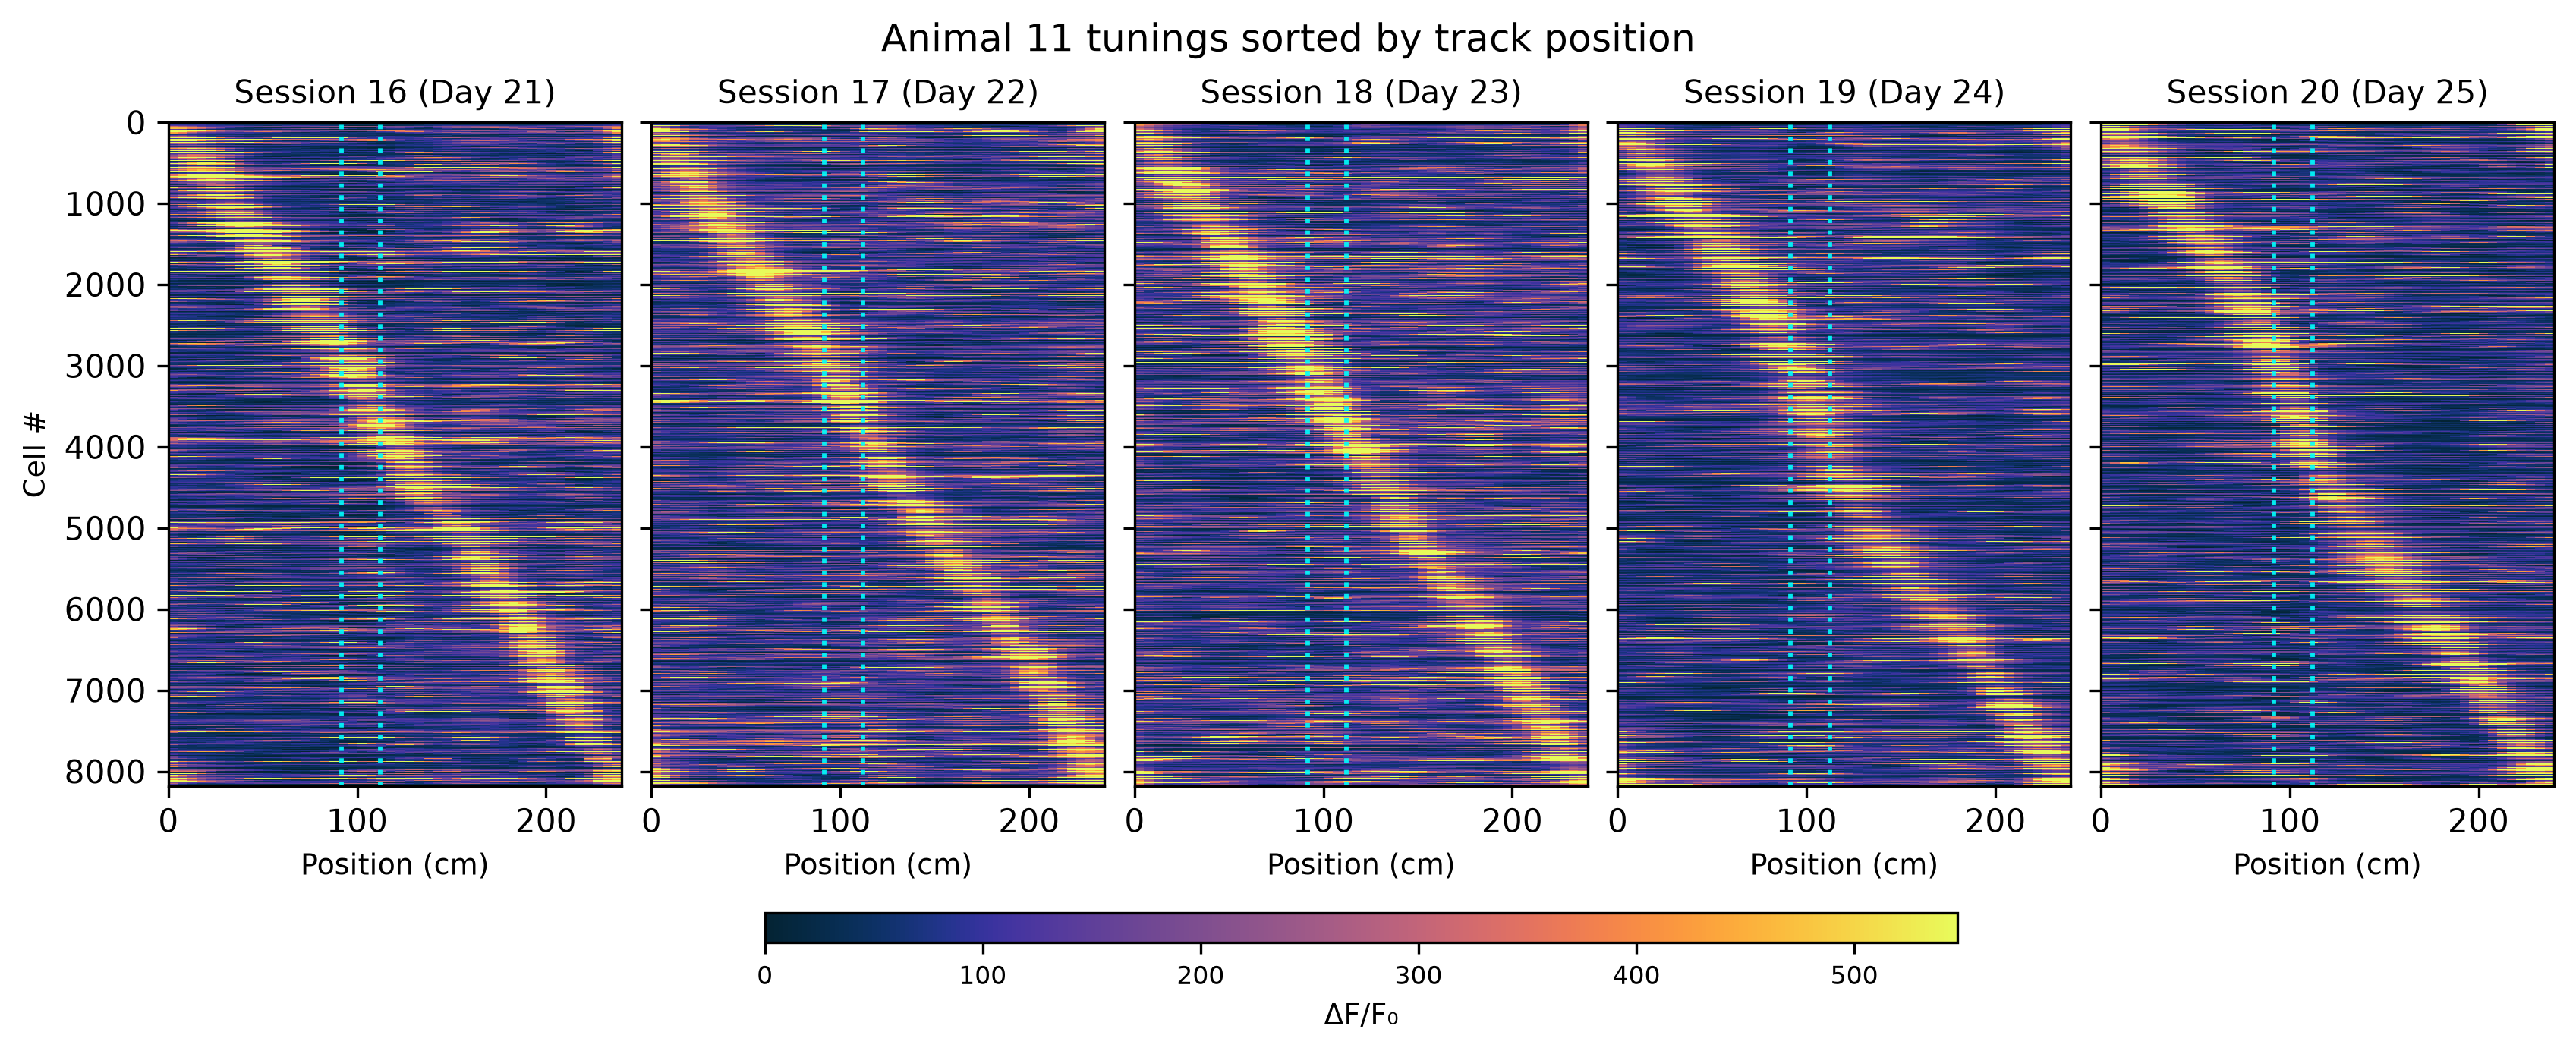

In [6]:
plot_sorted_heatmap(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=300,
    cmap="cmo.thermal",
)
plt.show()

### 5.2 Per-day-sorted rate maps — classified cells

Per-session view restricted to one classifier-active subset. ``classifier="place"`` always selects ``IS_STRICT_PLACE`` (place-field morphology + lap coverage + split-half stability + per-cell peak shuffle); ``classifier="reward"`` selects ``IS_REWARD_CELL``. Each cell's row is divided by its own peak so the colorbar is fixed at ``[0, 1]`` regardless of absolute ΔF/F₀ amplitude. Cell counts vary across panels (the active set differs by day), so the y-axis is tickless and the per-panel ``Session X (Day Y, n=N)`` title carries the count.

In [ ]:
plot_classified_heatmap(
    sessions=sessions,
    classifier="place",  # "place" → IS_STRICT_PLACE; switch to "reward" for IS_REWARD_CELL
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=200,
    cmap="cmo.thermal",
)
plt.show()

### 5.3 Place-cell peak-location distribution before vs after reward shift

Replicates the layout of Sun et al. 2022 (Nature) Fig. 1h: the entire track is partitioned into cue-aligned bins (one cue wide, no two adjacent cues sharing a bin), the fraction of strict-place cells whose rate-map peak falls in each bin is averaged across the supplied 'before' and 'after' session groups, and the two averages render as line traces with SEM error bars. Vertical dashed lines mark the trigger-zone center from each group's first session so a reward shift between groups reads off the figure directly.

Uses `BEFORE_SHIFT_SESSIONS` and `AFTER_SHIFT_SESSIONS` from the selection cell to pick which sessions to average.

In [ ]:
plot_place_cell_peak_distribution_around_shift(
    sessions=sessions,
    before_sessions=BEFORE_SHIFT_SESSIONS,
    after_sessions=AFTER_SHIFT_SESSIONS,
    trial_type=trial_type,
    animal_id=ANIMAL,
    figure_dpi=150,
)
plt.show()